# Do NOT use this notebook, it is buggy! use sif_buildup.ipynb instead !!!!!

# Worldmap Sea Ice Fraction Anomaly Plots

## Origin of Files

In [1]:
#Short history of commands and origin of files:
# The commands are for the PI dataset, the other datasets have been created exactly analogous 
# just the names of the files have been exchanged, they can be found in the folders
# /data/modeldata/ICON/icon-paleo/LIG.kepler/remapped_r2b4  &  ./data/modeldata/ICON/icon-paleo/LIG.kepler.ghg/remapped_r2b4

#
#Merging:
#        cdo mergetime ../PI.kepler.mk_atm_2d_ml_*.nc PI.kepler_atm2d_merged.nc
#
#Regridding:
#        getting gridfiles/icon_grid_0012_R02B04_G.nc
#                ==> downloaded original from ICON paleo website, is the gridfile for R02B04 grid
#        creating gridfiles/target_grid_1_5.txt
#                ==> got from Kiras 0.75 grid, changed numbers pretty self explanatory!
#
#        Creating weightfile in gridfiles:
#        cdo gendis,gridfiles/target_grid_1_5.txt -setgrid,gridfiles/icon_grid_0012_R02B04_G.nc  PI.kepler_atm2d_merged.nc gridfiles/weightfile_R02B04_to_1_5_deg
#
#        Actual Remapping:
#        cdo -remap,gridfiles/target_grid_1_5.txt,gridfiles/weightfile_R02B04_to_1_5_deg PI.kepler_atm2d_merged.nc PI.kepler_atm2d_merged_remapped.nc
#
#Selecting the relevant years:
#        cdo selyear,1770/1800 PI.kepler_atm2d_merged_remapped.nc PI.kepler_atm2d_merged_remapped_1770_1800.nc
#
#
#Extracting DIFFERENT data:
#
#        Creating Means:
#        cdo ymonmean PI.kepler_atm2d_merged_remapped_1770_1800.nc ymonmean_PI.kepler_atm2d_merged_remapped_1770_1800.nc
#



## Basic Import Statements

In [2]:
# %%
import xarray as xr
import numpy as np
#from scipy.stats import pearsonr
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
#from tqdm import tqdm
import os
import socket
import psutil
import cartopy.crs as ccrs
import cartopy.feature as cfeature

## Loading rcParams

In [3]:
import importlib
import plot_settings
importlib.reload(plot_settings)
plot_settings.load_rcParams()

## Loading Data (ymonmeans)

In [4]:
def determine_system() -> str:
    many_cores  = os.cpu_count() > 16
    lots_of_ram = psutil.virtual_memory().total > 64 * 1024**3  # more than 64 GB
    if many_cores and lots_of_ram:
        return 'Cluster'
    else:
        return 'Jakob_Laptop'

if determine_system() == 'Jakob_Laptop':
    location_of_data = '../'
else:
    location_of_data = '/data/modeldata/ICON/icon-paleo/'

print('Loading ymonmean Data')
PI      = xr.open_dataset(location_of_data + 'PI.kepler/remapped_r2b4/ymonmean_PI.kepler_atm2d_merged_remapped_1770_1800.nc')
LIG     = xr.open_dataset(location_of_data + 'LIG.kepler/remapped_r2b4/ymonmean_LIG.kepler_atm2d_merged_remapped_1770_1800.nc')
LIG_ghg = xr.open_dataset(location_of_data + 'LIG.kepler.ghg/remapped_r2b4/ymonmean_LIG.kepler.ghg_atm2d_merged_remapped_1770_1800.nc')



#PI  = xr.open_dataset('../PI.kepler/remapped_r2b4/ymonmean_PI.kepler_atm2d_merged_remapped_1770_1800.nc')
#LIG  = xr.open_dataset('../LIG.kepler/remapped_r2b4/ymonmean_LIG.kepler_atm2d_merged_remapped_1770_1800.nc')
#LIG_ghg = xr.open_dataset('../LIG.kepler.ghg/remapped_r2b4/ymonmean_LIG.kepler.ghg_atm2d_merged_remapped_1770_1800.nc')


Loading ymonmean Data


## Deriving Worldmap Anomalies

In [5]:
#extract Juli
def extract_month(PI: xr.DataArray, month: int = 7) -> xr.DataArray:
    PI_mon = PI.sel(time=PI.time.dt.month == month)
    return PI_mon

def remove_useless_dims(ds):
    if 'height_2' in PI.dims:
        ds = ds.squeeze('height_2')
    if 'height' in PI.dims:
        ds = ds.squeeze('height')
    return ds

def get_annual_mean(ds):
    #takes annual mean only for ymonmean data!
    return ds.mean(dim='time')

PI,LIG,LIG_ghg = [remove_useless_dims(ds) for ds in [PI,LIG,LIG_ghg]]


PI_Jul      = extract_month(PI,      month =7)
LIG_Jul     = extract_month(LIG,     month =7)
LIG_ghg_Jul = extract_month(LIG_ghg, month =7)

PI_Jan      = extract_month(PI,      month =1)
LIG_Jan     = extract_month(LIG,     month =1)
LIG_ghg_Jan = extract_month(LIG_ghg, month =1)

PI_ann,LIG_ann,LIG_ghg_ann = [get_annual_mean(ds) for ds in [PI,LIG,LIG_ghg]] #ann stands for annual not Anomaly




# derive anomaly
Anom_Jul_LIG_PI = LIG_Jul - PI_Jul
Anom_Jan_LIG_PI = LIG_Jan - PI_Jan
Anom_ann_LIG_PI = LIG_ann - PI_ann



In [12]:
#PI = PI.squeeze('height_2')

## Plotting Sea Ice Fraction: Annual, Juli and January Mean

/tmp/ipykernel_6982/1466087593.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


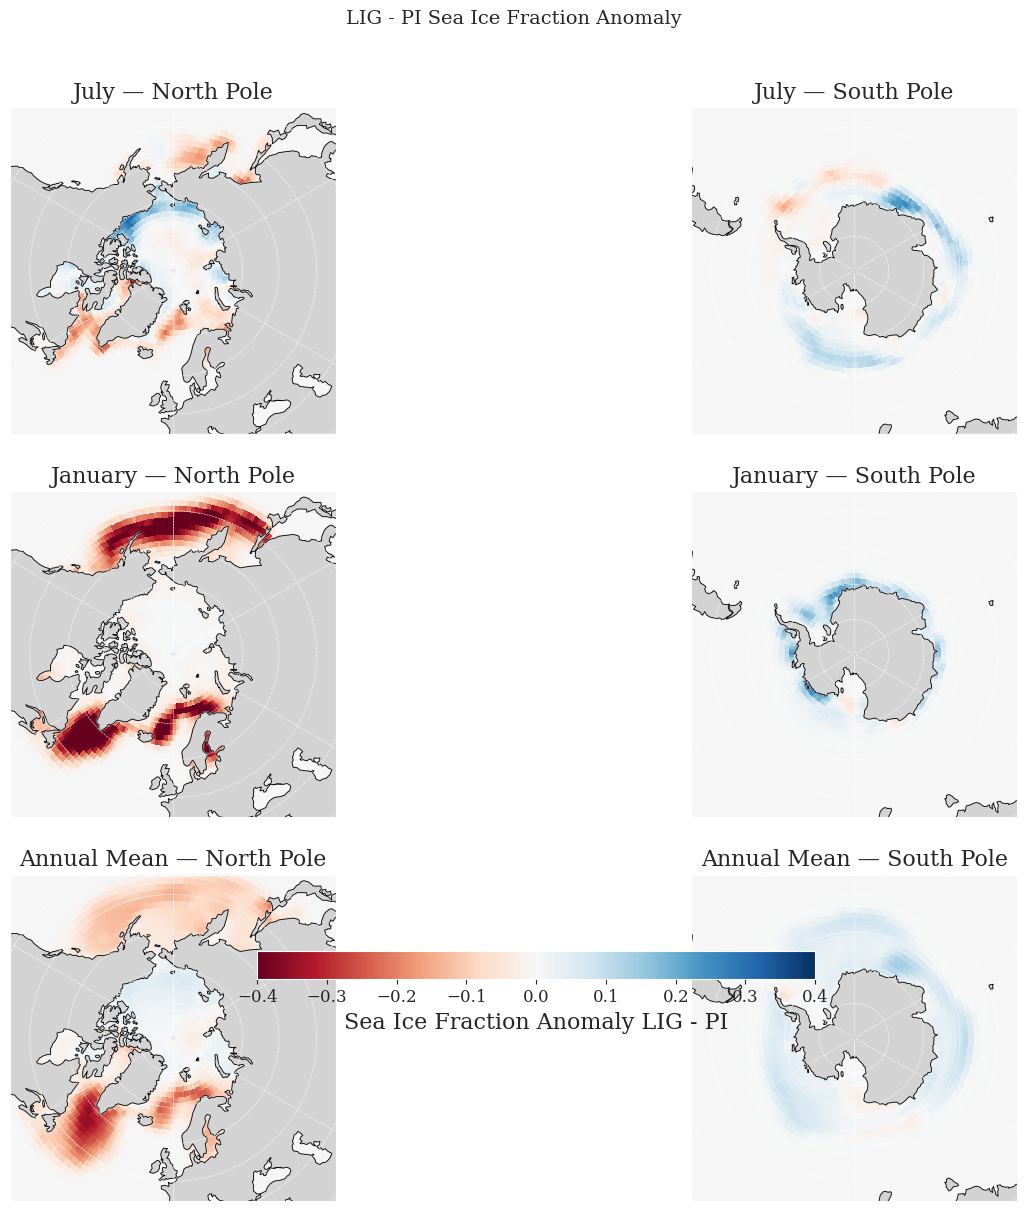

In [13]:
fig = plt.figure(figsize=(18, 12))

datasets = [
    (Anom_Jul_LIG_PI, "July"),
    (Anom_Jan_LIG_PI, "January"),
    (Anom_ann_LIG_PI, "Annual Mean"),
]

axes_pairs = []
for i, (ds, title) in enumerate(datasets):
    ax_north = fig.add_subplot(3, 2, i*2 + 1, projection=ccrs.NorthPolarStereo())
    ax_south = fig.add_subplot(3, 2, i*2 + 2, projection=ccrs.SouthPolarStereo())
    axes_pairs.append((ax_north, ax_south, ds, title))

vmax = 0.4  # adjust to your data range
norm = plt.Normalize(-vmax, vmax)

for ax_north, ax_south, ds, title in axes_pairs:
    sif = ds["fr_seaice"].squeeze()
    for ax, extent in zip([ax_north, ax_south], [[-180, 180, 45, 90], [-180, 180, -90, -45]]):
        sif.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cmap="RdBu_r",
            norm=norm,
            add_colorbar=False
        )
        ax.set_extent(extent, crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
        ax.add_feature(cfeature.LAND, color="lightgray", zorder=1)
        ax.gridlines(linewidth=0.4, linestyle="--")

    ax_north.set_title(f"{title} — North Pole")
    ax_south.set_title(f"{title} — South Pole")

# Shared colorbar
sm = plt.cm.ScalarMappable(cmap="RdBu", norm=norm)
fig.colorbar(sm, ax=fig.get_axes(), orientation="horizontal",
             label="Sea Ice Fraction Anomaly LIG - PI", pad=0.05, shrink=0.4)

plt.suptitle("LIG - PI Sea Ice Fraction Anomaly", y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig('figs/Sea_Ice_Fraction_Anomaly.png')

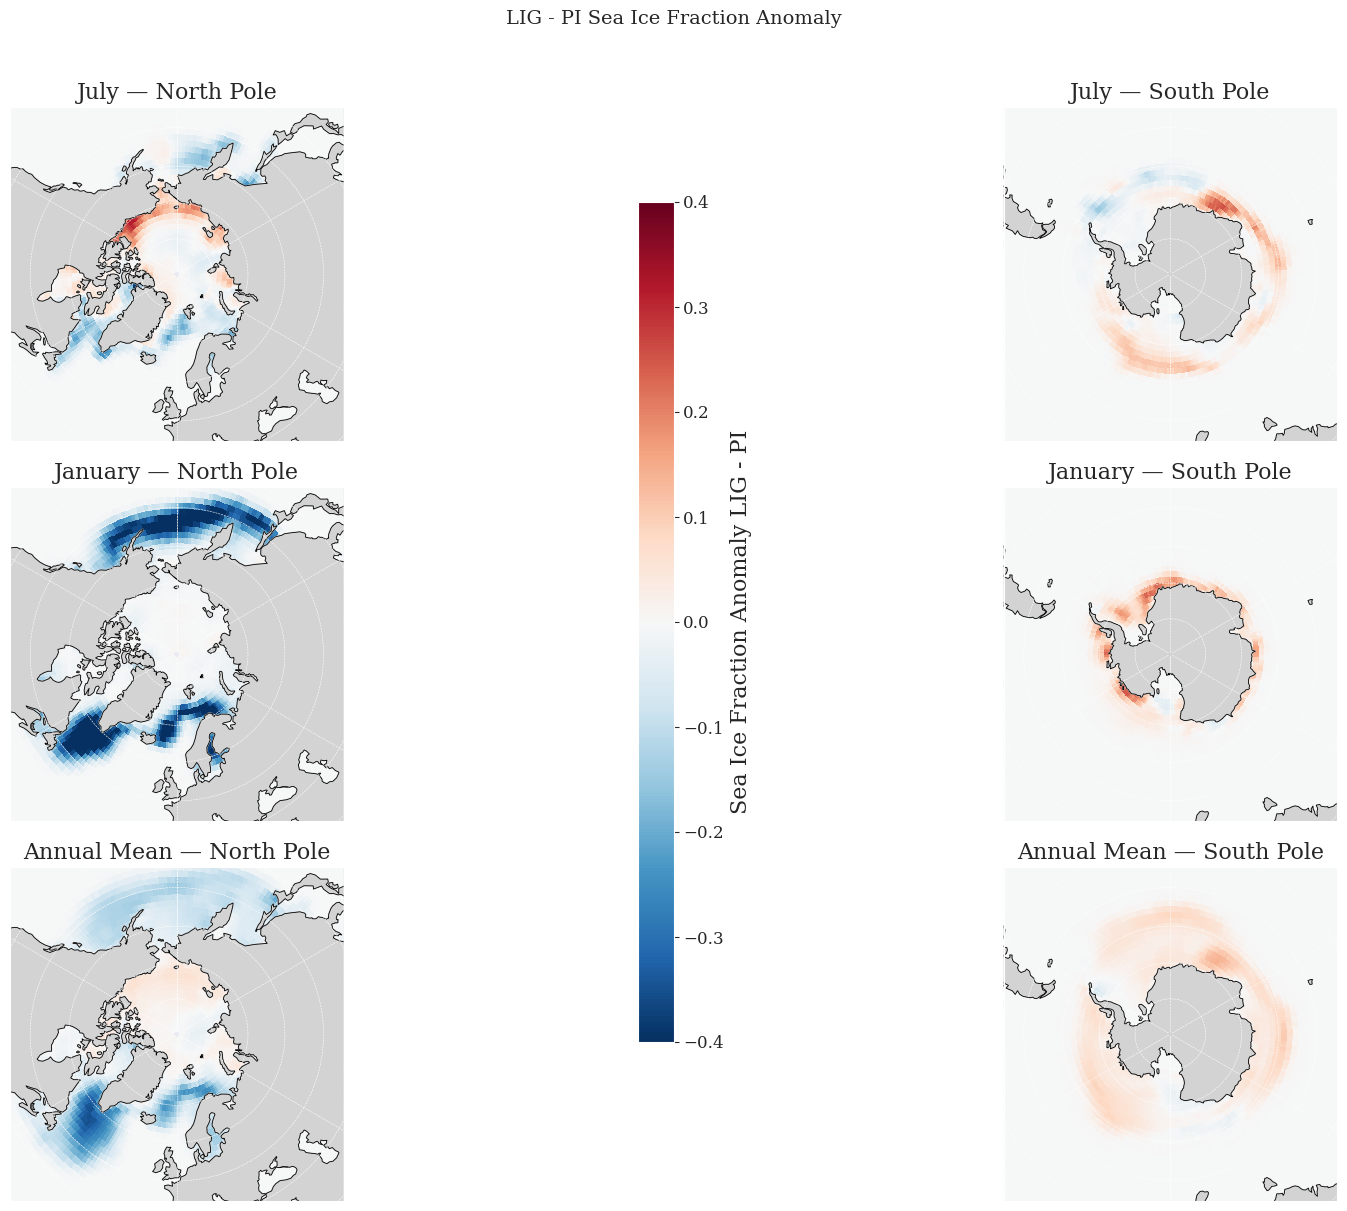

In [14]:

fig = plt.figure(figsize=(18, 12))

datasets = [
    (Anom_Jul_LIG_PI, "July"),
    (Anom_Jan_LIG_PI, "January"),
    (Anom_ann_LIG_PI, "Annual Mean"),
]

axes_pairs = []
for i, (ds, title) in enumerate(datasets):
    ax_north = fig.add_subplot(3, 2, i*2 + 1, projection=ccrs.NorthPolarStereo())
    ax_south = fig.add_subplot(3, 2, i*2 + 2, projection=ccrs.SouthPolarStereo())
    axes_pairs.append((ax_north, ax_south, ds, title))

vmax = 0.4  # adjust to your data range
norm = plt.Normalize(-vmax, vmax)

for ax_north, ax_south, ds, title in axes_pairs:
    sif = ds["fr_seaice"].squeeze()
    for ax, extent in zip([ax_north, ax_south], [[-180, 180, 45, 90], [-180, 180, -90, -45]]):
        sif.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cmap="RdBu",
            norm=norm,
            add_colorbar=False
        )
        ax.set_extent(extent, crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
        ax.add_feature(cfeature.LAND, color="lightgray", zorder=1)
        ax.gridlines(linewidth=0.4, linestyle="--")

    ax_north.set_title(f"{title} — North Pole")
    ax_south.set_title(f"{title} — South Pole")

plt.suptitle("LIG - PI Sea Ice Fraction Anomaly", y=1.01, fontsize=14)
plt.tight_layout()

# Vertical colorbar in the middle
fig.subplots_adjust(wspace=0.3)
sm = plt.cm.ScalarMappable(cmap="RdBu_r", norm=norm)
cbar_ax = fig.add_axes([0.48, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(sm, cax=cbar_ax, orientation="vertical",
             label="Sea Ice Fraction Anomaly LIG - PI")

#plt.savefig('figs/Sea_Ice_Fraction_Anomaly.png', bbox_inches='tight')



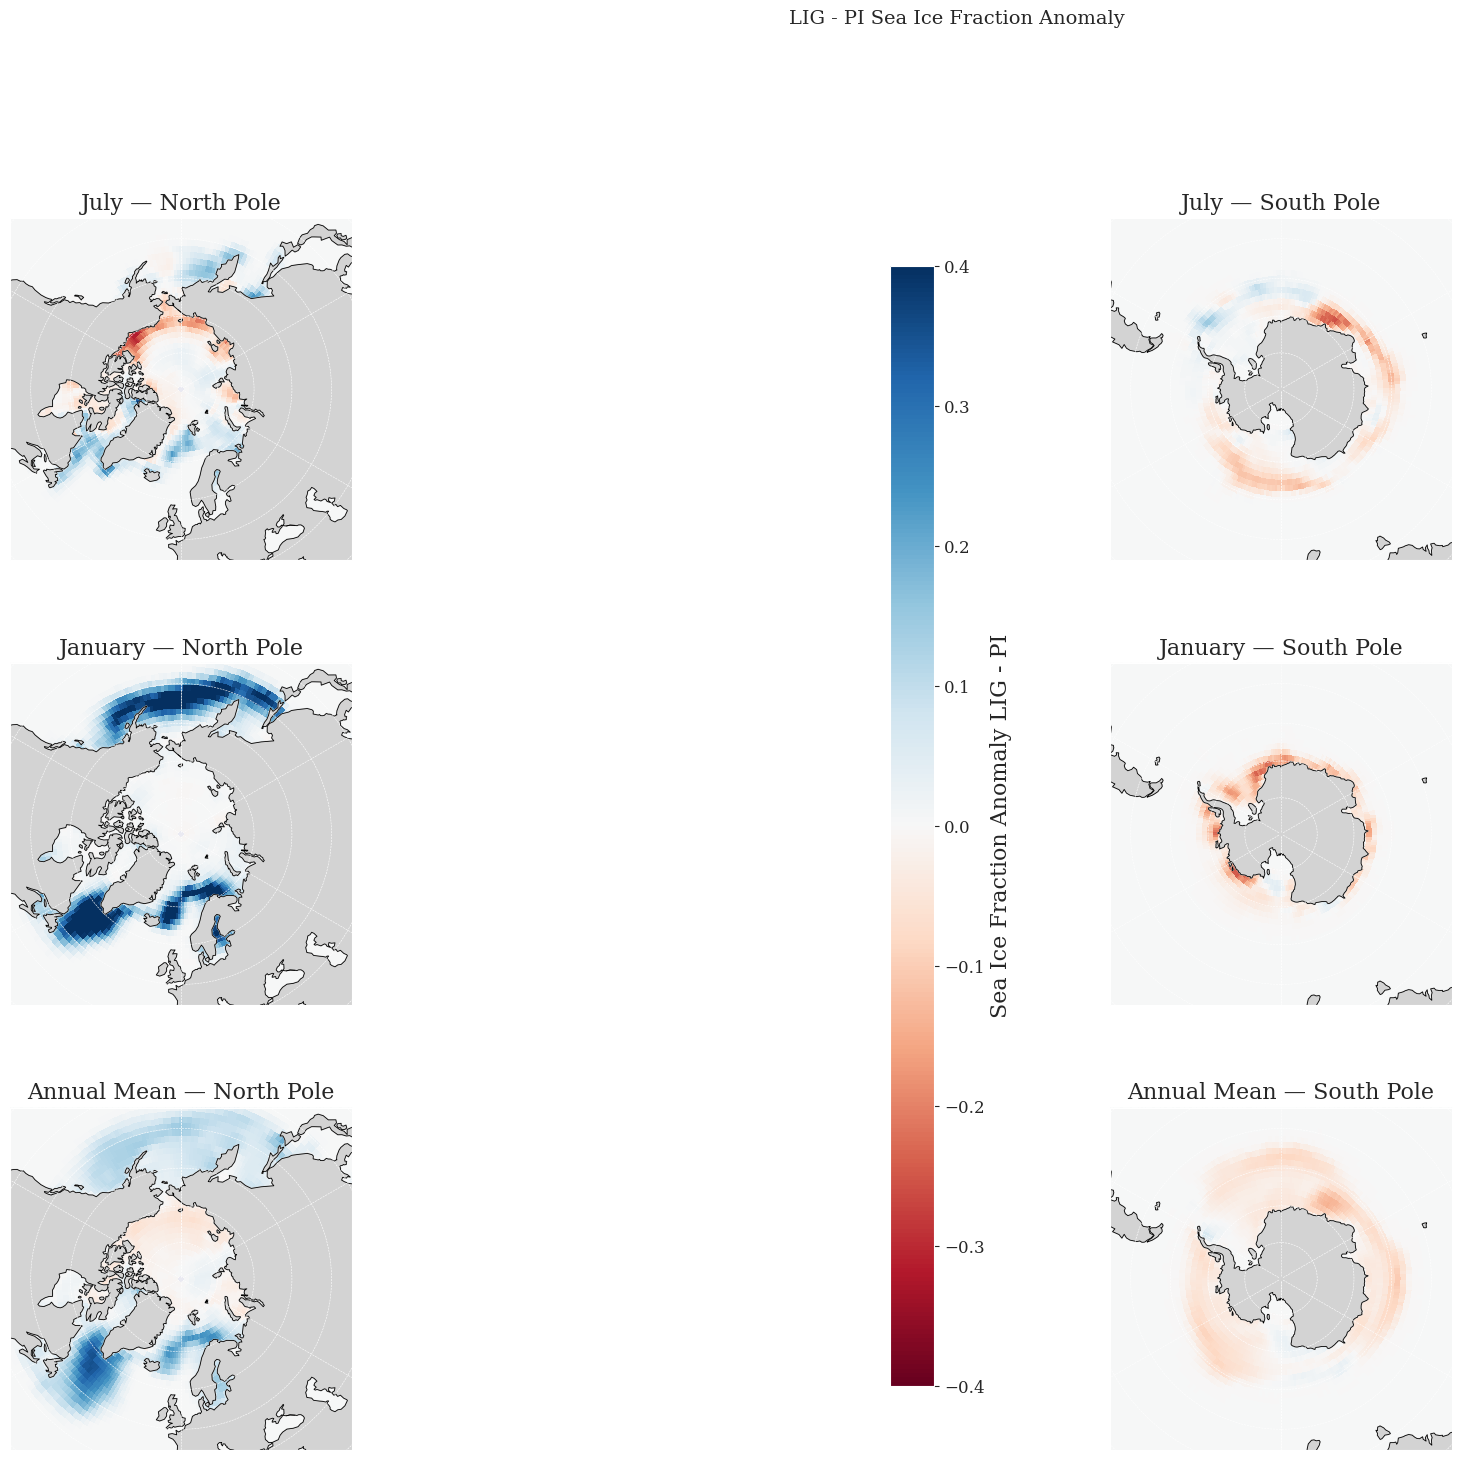

In [11]:
fig = plt.figure(figsize=(22, 16))

datasets = [
    (Anom_Jul_LIG_PI, "July"),
    (Anom_Jan_LIG_PI, "January"),
    (Anom_ann_LIG_PI, "Annual Mean"),
]

# Use gridspec to control column widths — wide gap in middle for colorbar
gs = fig.add_gridspec(3, 2, wspace=0.05, hspace=0.3,
                      left=0.05, right=0.45,  # left column group
                      )
gs2 = fig.add_gridspec(3, 2, wspace=0.05, hspace=0.3,
                       left=0.55, right=0.95,  # right column group
                       )

axes_pairs = []
for i, (ds, title) in enumerate(datasets):
    ax_north = fig.add_subplot(gs[i, 0], projection=ccrs.NorthPolarStereo())
    ax_south = fig.add_subplot(gs2[i, 0], projection=ccrs.SouthPolarStereo())
    axes_pairs.append((ax_north, ax_south, ds, title))

vmax = 0.4
norm = plt.Normalize(-vmax, vmax)

for ax_north, ax_south, ds, title in axes_pairs:
    sif = ds["fr_seaice"].squeeze()
    for ax, extent in zip([ax_north, ax_south], [[-180, 180, 45, 90], [-180, 180, -90, -45]]):
        sif.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cmap="RdBu",
            norm=norm,
            add_colorbar=False
        )
        ax.set_extent(extent, crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
        ax.add_feature(cfeature.LAND, color="lightgray", zorder=1)
        ax.gridlines(linewidth=0.4, linestyle="--")

    ax_north.set_title(f"{title} — North Pole")
    ax_south.set_title(f"{title} — South Pole")

plt.suptitle("LIG - PI Sea Ice Fraction Anomaly", y=1.01, fontsize=14)

# Vertical colorbar in the middle
sm = plt.cm.ScalarMappable(cmap="RdBu", norm=norm)
cbar_ax = fig.add_axes([0.47, 0.15, 0.02, 0.7])
fig.colorbar(sm, cax=cbar_ax, orientation="vertical",
             label="Sea Ice Fraction Anomaly LIG - PI")

#plt.savefig('figs/Sea_Ice_Fraction_Anomaly.png', bbox_inches='tight')